#BONS CHERRY — Modified vs Plan Profile Builder

JupyterLite / CSV-only workflow.

This notebook:
- matches wells **by Well Name only**
- uses the same CTB well list for both cases
- builds a **Modified Profile** from the original production + forecast CSVs
- builds a **Plan Profile** from `SilvertipPlansProduction.csv` + `SilvertipPlansForecast.csv`
- uses actual production through each well's last actual month, then forecast after that
- builds **600 months (50 years)** per well
- aggregates all wells by calendar month
- converts monthly oil/gas volumes to average daily rates
- plots Modified and Plan oil/gas profiles separately
- plots Modified vs Plan together with the **delta shaded red**, regardless of which profile is higher
- saves aggregate, well-level, QA, and comparison outputs as CSV files

Upload all required CSVs into the same JupyterLite folder before running.

## 1. Imports and file names

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

PROFILE_MONTHS = 600

# ------------------------------------------------------------
# EDIT THESE FILENAMES IF YOUR FILES HAVE DIFFERENT NAMES
# ------------------------------------------------------------

WELL_LIST_FILE = 'BONS CHERRY WELLS.csv'                 # CTB well list
MODIFIED_PRODUCTION_FILE = 'BONS CHERRY MY PRD.csv'      # original actual production
MODIFIED_FORECAST_FILE = 'bonscher_MY_FRCST_highside.csv'          # original modified forecast
PLAN_PRODUCTION_FILE = 'BONS CHERRY PLAN PRD.csv'
PLAN_FORECAST_FILE = 'BONS CHERRY PLAN FRCST.csv'

print('File assignments loaded.')

os.chdir('/drive/BONS CHERRY')

print("Current directory", os.getcwd())
print(os.listdir())

File assignments loaded.
Current directory /drive/BONS CHERRY
['BONS CHERRY MY FRCST.csv', 'BONS CHERRY MY PRD.csv', 'BONS CHERRY PLAN FRCST.csv', 'BONS CHERRY PLAN PRD.csv', 'BONS CHERRY WELLS.csv', 'BonsCher_Modified_vs_Plan_JupyterLite_with_Cumulative.ipynb', 'Silvertip_Cumulative_Delta_Summary.csv', 'Silvertip_Modified_vs_Plan_Comparison.csv', 'bonscher_MY_FRCST_highside.csv']


## 2. Helper functions

In [15]:
def normalize_well_name(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = re.sub(r'\s+', ' ', value)
    return value.upper()


def parse_date(series):
    parsed = pd.to_datetime(series, errors='coerce')
    return parsed.dt.to_period('M').dt.to_timestamp()


def prepare_combo_csv(filename):
    """
    ComboCurve-style CSV:
    A = Well Name
    H = Date
    I = Oil BBL/month
    J = Gas MCF/month
    """
    raw = pd.read_csv(filename)

    if raw.shape[1] < 10:
        raise ValueError(f'{filename} does not contain at least columns A-J.')

    df = raw.iloc[:, [0, 7, 8, 9]].copy()
    df.columns = ['Well_Name', 'Date', 'Oil_BBL', 'Gas_MCF']

    df['Match_Name'] = df['Well_Name'].apply(normalize_well_name)
    df['Date'] = parse_date(df['Date'])
    df['Oil_BBL'] = pd.to_numeric(df['Oil_BBL'], errors='coerce').fillna(0)
    df['Gas_MCF'] = pd.to_numeric(df['Gas_MCF'], errors='coerce').fillna(0)

    df = df[df['Match_Name'].notna() & df['Date'].notna()].copy()

    df = (
        df.groupby(['Match_Name', 'Date'], as_index=False)[['Oil_BBL', 'Gas_MCF']]
        .sum()
    )

    return df


def build_case_profile(case_name, production_df, forecast_df, ctb_wells, profile_months=600):
    all_profiles = []
    qa_rows = []

    for _, well_row in ctb_wells.iterrows():
        original_name = well_row['Well_Name']
        match_name = well_row['Match_Name']

        prod_well = production_df[production_df['Match_Name'] == match_name].copy().sort_values('Date')
        fcst_well = forecast_df[forecast_df['Match_Name'] == match_name].copy().sort_values('Date')

        found_prod = len(prod_well) > 0
        found_fcst = len(fcst_well) > 0

        if found_prod:
            profile_start = prod_well['Date'].min()
        elif found_fcst:
            profile_start = fcst_well['Date'].min()
        else:
            qa_rows.append({
                'Case': case_name,
                'Well_Name': original_name,
                'Found_Production': False,
                'Found_Forecast': False,
                'Profile_Start': pd.NaT,
                'Last_Actual_Month': pd.NaT,
                'First_Forecast_Month_Used': pd.NaT,
                'Final_Profile_Months': 0,
                'Oil_BBL_50yr': 0,
                'Gas_MCF_50yr': 0,
                'QA_Status': 'MISSING FROM BOTH FILES'
            })
            continue

        monthly_dates = pd.date_range(start=profile_start, periods=profile_months, freq='MS')
        profile = pd.DataFrame({'Date': monthly_dates})
        profile['Well_Name'] = original_name
        profile['Case'] = case_name

        last_actual = prod_well['Date'].max() if found_prod else pd.NaT

        prod_temp = prod_well[['Date', 'Oil_BBL', 'Gas_MCF']].rename(columns={
            'Oil_BBL': 'Actual_Oil_BBL',
            'Gas_MCF': 'Actual_Gas_MCF'
        })
        fcst_temp = fcst_well[['Date', 'Oil_BBL', 'Gas_MCF']].rename(columns={
            'Oil_BBL': 'Forecast_Oil_BBL',
            'Gas_MCF': 'Forecast_Gas_MCF'
        })

        profile = profile.merge(prod_temp, on='Date', how='left')
        profile = profile.merge(fcst_temp, on='Date', how='left')

        if found_prod:
            actual_mask = profile['Date'] <= last_actual
            forecast_mask = profile['Date'] > last_actual
        else:
            actual_mask = pd.Series(False, index=profile.index)
            forecast_mask = pd.Series(True, index=profile.index)

        profile['Oil_BBL'] = 0.0
        profile['Gas_MCF'] = 0.0
        profile['Data_Source'] = ''

        profile.loc[actual_mask, 'Oil_BBL'] = profile.loc[actual_mask, 'Actual_Oil_BBL'].fillna(0)
        profile.loc[actual_mask, 'Gas_MCF'] = profile.loc[actual_mask, 'Actual_Gas_MCF'].fillna(0)
        profile.loc[actual_mask, 'Data_Source'] = 'Actual'

        profile.loc[forecast_mask, 'Oil_BBL'] = profile.loc[forecast_mask, 'Forecast_Oil_BBL'].fillna(0)
        profile.loc[forecast_mask, 'Gas_MCF'] = profile.loc[forecast_mask, 'Forecast_Gas_MCF'].fillna(0)
        profile.loc[forecast_mask, 'Data_Source'] = 'Forecast'

        first_forecast_used = last_actual + pd.offsets.MonthBegin(1) if found_prod else profile_start

        missing_fcst_after_actual = False
        if found_prod:
            required_dates = set(profile.loc[profile['Date'] > last_actual, 'Date'])
            fcst_dates_available = set(fcst_well['Date'])
            if not required_dates.issubset(fcst_dates_available):
                missing_fcst_after_actual = True

        if not found_fcst:
            status = 'NO FORECAST FOUND'
        elif missing_fcst_after_actual:
            status = 'FORECAST DOES NOT COVER FULL 50 YEARS'
        elif not found_prod:
            status = 'NO ACTUALS - FORECAST ONLY'
        else:
            status = 'OK'

        qa_rows.append({
            'Case': case_name,
            'Well_Name': original_name,
            'Found_Production': found_prod,
            'Found_Forecast': found_fcst,
            'Profile_Start': profile_start,
            'Last_Actual_Month': last_actual,
            'First_Forecast_Month_Used': first_forecast_used,
            'Final_Profile_Months': len(profile),
            'Oil_BBL_50yr': profile['Oil_BBL'].sum(),
            'Gas_MCF_50yr': profile['Gas_MCF'].sum(),
            'QA_Status': status
        })

        all_profiles.append(
            profile[['Case', 'Well_Name', 'Date', 'Data_Source', 'Oil_BBL', 'Gas_MCF']]
        )

    if len(all_profiles) == 0:
        raise ValueError(f'No wells matched for {case_name}.')

    well_level = pd.concat(all_profiles, ignore_index=True)
    qa = pd.DataFrame(qa_rows)

    aggregated = (
        well_level.groupby('Date', as_index=False)[['Oil_BBL', 'Gas_MCF']]
        .sum()
        .sort_values('Date')
    )

    aggregated['Days_In_Month'] = aggregated['Date'].dt.days_in_month
    aggregated['Oil_BPD'] = aggregated['Oil_BBL'] / aggregated['Days_In_Month']
    aggregated['Gas_MCFD'] = aggregated['Gas_MCF'] / aggregated['Days_In_Month']
    aggregated['Cum_Oil_BBL'] = aggregated['Oil_BBL'].cumsum()
    aggregated['Cum_Gas_MCF'] = aggregated['Gas_MCF'].cumsum()
    aggregated['Case'] = case_name

    return well_level, qa, aggregated


## 3. Load CTB well list

In [16]:
well_list_raw = pd.read_csv(WELL_LIST_FILE)

well_name_candidates = [
    c for c in well_list_raw.columns
    if 'well' in str(c).lower() and 'name' in str(c).lower()
]

if len(well_name_candidates) > 0:
    well_list_name_col = well_name_candidates[0]
elif well_list_raw.shape[1] >= 3:
    well_list_name_col = well_list_raw.columns[2]
else:
    raise ValueError('Could not determine the Well Name column in the CTB well list.')

ctb_wells = well_list_raw[[well_list_name_col]].copy()
ctb_wells.columns = ['Well_Name']
ctb_wells['Well_Name'] = ctb_wells['Well_Name'].astype(str).str.strip()
ctb_wells = ctb_wells[
    ctb_wells['Well_Name'].notna()
    & (ctb_wells['Well_Name'] != '')
    & (ctb_wells['Well_Name'].str.lower() != 'nan')
].copy()
ctb_wells['Match_Name'] = ctb_wells['Well_Name'].apply(normalize_well_name)
ctb_wells = ctb_wells.drop_duplicates('Match_Name').reset_index(drop=True)

print('Using well name column:', well_list_name_col)
print('CTB wells found:', len(ctb_wells))
display(ctb_wells.head())

Using well name column: Well Name
CTB wells found: 12


,Well_Name,Match_Name
0,BIG CYPRESS 56-2-13 1H,BIG CYPRESS 56-2-13 1H
1,BONSAI 56-2-13-25 A 13H,BONSAI 56-2-13-25 A 13H
2,BONSAI 56-2-13-25 B 14H,BONSAI 56-2-13-25 B 14H
3,BONSAI 56-2-13-25 C 15H,BONSAI 56-2-13-25 C 15H
4,BONSAI 56-2-13-25 D 22H,BONSAI 56-2-13-25 D 22H


## 4. Load Modified and Plan production / forecast CSVs

In [17]:
modified_production = prepare_combo_csv(MODIFIED_PRODUCTION_FILE)
modified_forecast = prepare_combo_csv(MODIFIED_FORECAST_FILE)
plan_production = prepare_combo_csv(PLAN_PRODUCTION_FILE)
plan_forecast = prepare_combo_csv(PLAN_FORECAST_FILE)

print('Modified production rows:', len(modified_production))
print('Modified forecast rows:', len(modified_forecast))
print('Plan production rows:', len(plan_production))
print('Plan forecast rows:', len(plan_forecast))

Modified production rows: 586
Modified forecast rows: 6871
Plan production rows: 586
Plan forecast rows: 6828


## 5. Build Modified Profile

In [18]:
modified_well_level, modified_qa, modified_aggregated = build_case_profile(
    'Modified Profile',
    modified_production,
    modified_forecast,
    ctb_wells,
    PROFILE_MONTHS
)

print('Modified wells included:', modified_well_level['Well_Name'].nunique())
print(modified_qa['QA_Status'].value_counts(dropna=False))

Modified wells included: 12
QA_Status
OK    12
Name: count, dtype: int64


## 6. Build Plan Profile

In [19]:
plan_well_level, plan_qa, plan_aggregated = build_case_profile(
    'Plan Profile',
    plan_production,
    plan_forecast,
    ctb_wells,
    PROFILE_MONTHS
)

print('Plan wells included:', plan_well_level['Well_Name'].nunique())
print(plan_qa['QA_Status'].value_counts(dropna=False))

Plan wells included: 12
QA_Status
OK    12
Name: count, dtype: int64


## 7. Plot Modified Profile by itself

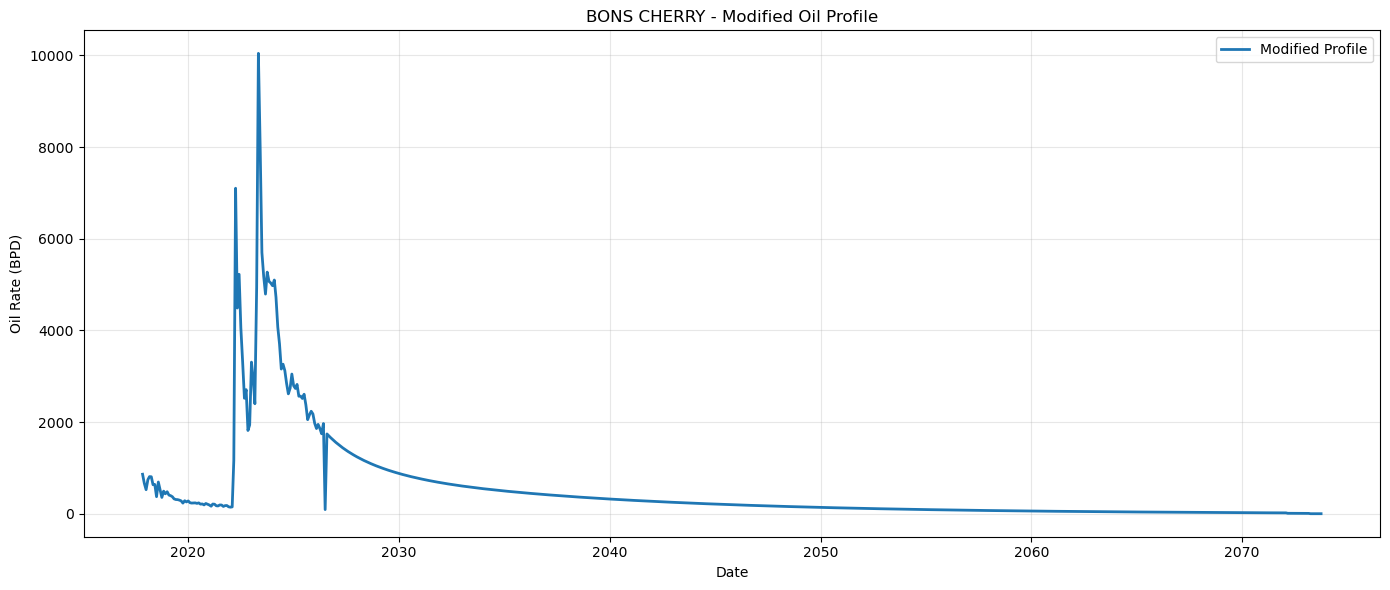

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(modified_aggregated['Date'], modified_aggregated['Oil_BPD'], label='Modified Profile', linewidth=2)
plt.title('BONS CHERRY - Modified Oil Profile')
plt.xlabel('Date')
plt.ylabel('Oil Rate (BPD)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

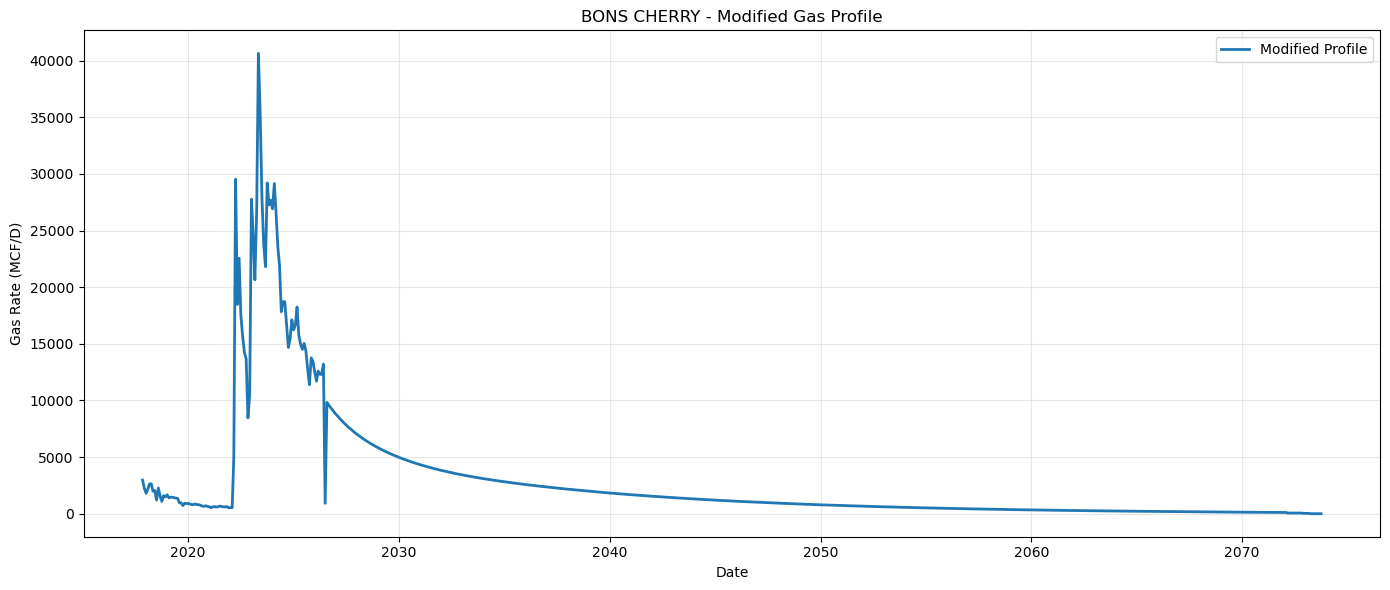

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(modified_aggregated['Date'], modified_aggregated['Gas_MCFD'], label='Modified Profile', linewidth=2)
plt.title('BONS CHERRY - Modified Gas Profile')
plt.xlabel('Date')
plt.ylabel('Gas Rate (MCF/D)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Plot Plan Profile by itself

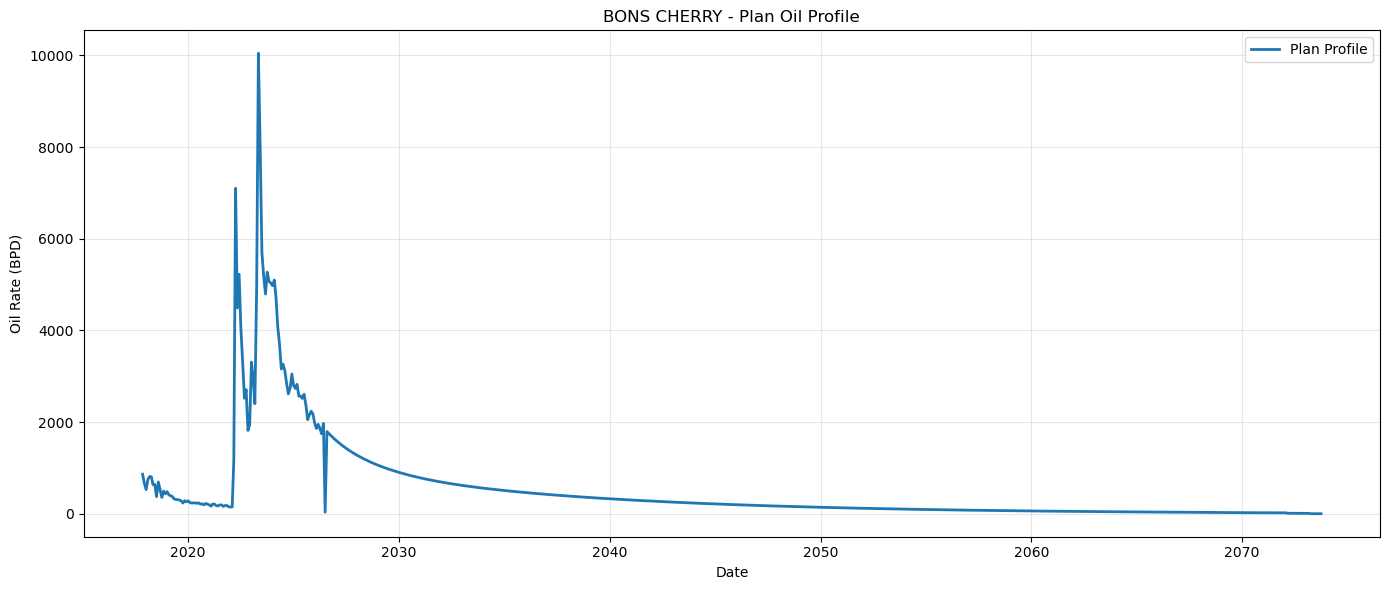

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(plan_aggregated['Date'], plan_aggregated['Oil_BPD'], label='Plan Profile', linewidth=2)
plt.title('BONS CHERRY - Plan Oil Profile')
plt.xlabel('Date')
plt.ylabel('Oil Rate (BPD)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

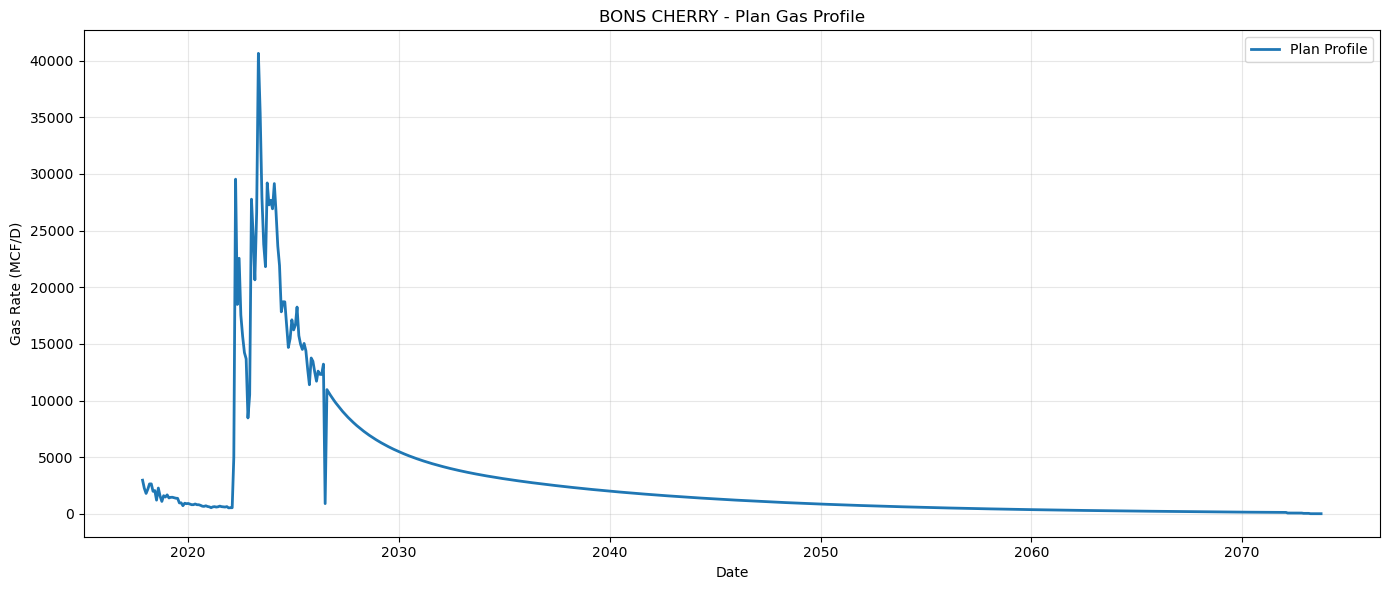

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(plan_aggregated['Date'], plan_aggregated['Gas_MCFD'], label='Plan Profile', linewidth=2)
plt.title('BONS CHERRY - Plan Gas Profile')
plt.xlabel('Date')
plt.ylabel('Gas Rate (MCF/D)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Align Modified and Plan profiles by calendar month

In [24]:
comparison = pd.merge(
    modified_aggregated[['Date', 'Oil_BPD', 'Gas_MCFD', 'Oil_BBL', 'Gas_MCF']],
    plan_aggregated[['Date', 'Oil_BPD', 'Gas_MCFD', 'Oil_BBL', 'Gas_MCF']],
    on='Date',
    how='outer',
    suffixes=('_Modified', '_Plan')
).sort_values('Date').reset_index(drop=True)

value_columns = [
    'Oil_BPD_Modified', 'Oil_BPD_Plan',
    'Gas_MCFD_Modified', 'Gas_MCFD_Plan',
    'Oil_BBL_Modified', 'Oil_BBL_Plan',
    'Gas_MCF_Modified', 'Gas_MCF_Plan'
]

comparison[value_columns] = comparison[value_columns].fillna(0)

comparison['Oil_Delta_BPD'] = comparison['Oil_BPD_Modified'] - comparison['Oil_BPD_Plan']
comparison['Gas_Delta_MCFD'] = comparison['Gas_MCFD_Modified'] - comparison['Gas_MCFD_Plan']
comparison['Oil_Delta_BBL'] = comparison['Oil_BBL_Modified'] - comparison['Oil_BBL_Plan']
comparison['Gas_Delta_MCF'] = comparison['Gas_MCF_Modified'] - comparison['Gas_MCF_Plan']

display(comparison.head(12))

,Date,Oil_BPD_Modified,Gas_MCFD_Modified,Oil_BBL_Modified,Gas_MCF_Modified,Oil_BPD_Plan,Gas_MCFD_Plan,Oil_BBL_Plan,Gas_MCF_Plan,Oil_Delta_BPD,Gas_Delta_MCFD,Oil_Delta_BBL,Gas_Delta_MCF
0,2017-11-01,863.566667,2973.366667,25907.0,89201.0,863.566667,2973.366667,25907.0,89201.0,0.0,0.0,0.0,0.0
1,2017-12-01,665.516129,2260.064516,20631.0,70062.0,665.516129,2260.064516,20631.0,70062.0,0.0,0.0,0.0,0.0
2,2018-01-01,526.354839,1802.645161,16317.0,55882.0,526.354839,1802.645161,16317.0,55882.0,0.0,0.0,0.0,0.0
3,2018-02-01,744.750000,2194.857143,20853.0,61456.0,744.750000,2194.857143,20853.0,61456.0,0.0,0.0,0.0,0.0
4,2018-03-01,811.451613,2643.193548,25155.0,81939.0,811.451613,2643.193548,25155.0,81939.0,0.0,0.0,0.0,0.0
5,2018-04-01,808.800000,2646.733333,24264.0,79402.0,808.800000,2646.733333,24264.0,79402.0,0.0,0.0,0.0,0.0
6,2018-05-01,634.290323,1996.064516,19663.0,61878.0,634.290323,1996.064516,19663.0,61878.0,0.0,0.0,0.0,0.0
7,2018-06-01,640.333333,2055.666667,19210.0,61670.0,640.333333,2055.666667,19210.0,61670.0,0.0,0.0,0.0,0.0
8,2018-07-01,373.677419,1212.774194,11584.0,37596.0,373.677419,1212.774194,11584.0,37596.0,0.0,0.0,0.0,0.0
9,2018-08-01,693.548387,2279.645161,21500.0,70669.0,693.548387,2279.645161,21500.0,70669.0,0.0,0.0,0.0,0.0


## 10. Modified vs Plan — Oil with red delta shading

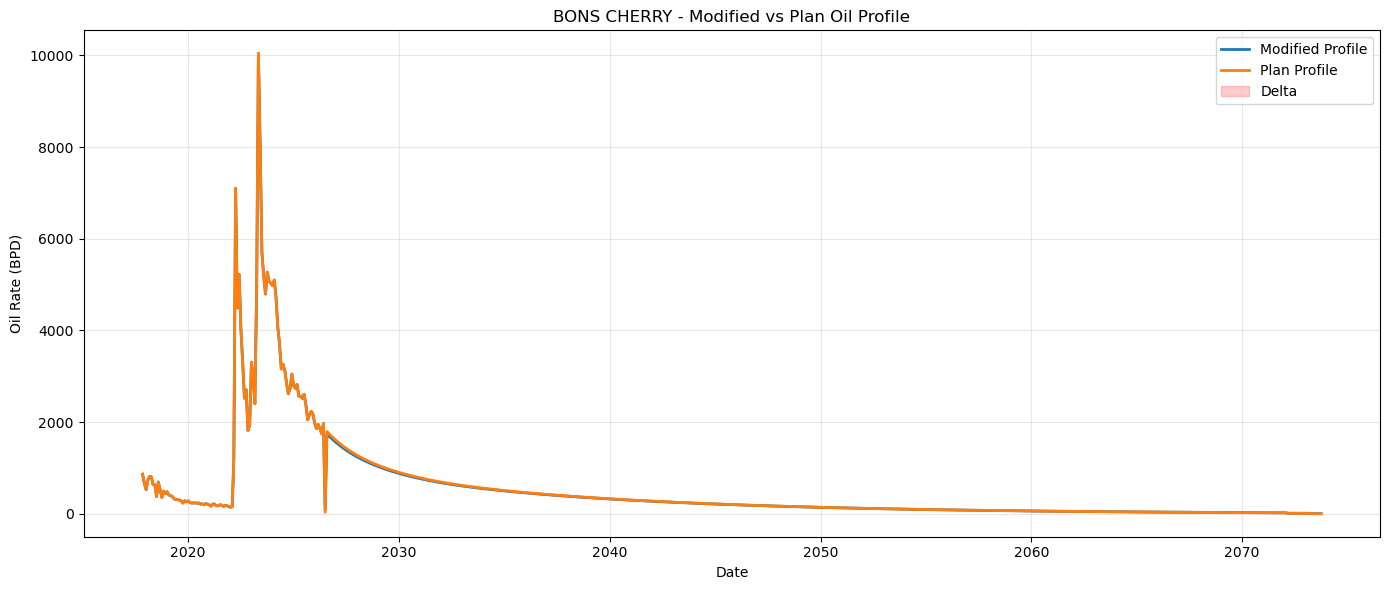

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison['Date'],
    comparison['Oil_BPD_Modified'],
    label='Modified Profile',
    linewidth=2
)

plt.plot(
    comparison['Date'],
    comparison['Oil_BPD_Plan'],
    label='Plan Profile',
    linewidth=2
)

plt.fill_between(
    comparison['Date'],
    comparison['Oil_BPD_Modified'],
    comparison['Oil_BPD_Plan'],
    color='red',
    alpha=0.20,
    label='Delta'
)

plt.title('BONS CHERRY - Modified vs Plan Oil Profile')
plt.xlabel('Date')
plt.ylabel('Oil Rate (BPD)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Modified vs Plan — Gas with red delta shading

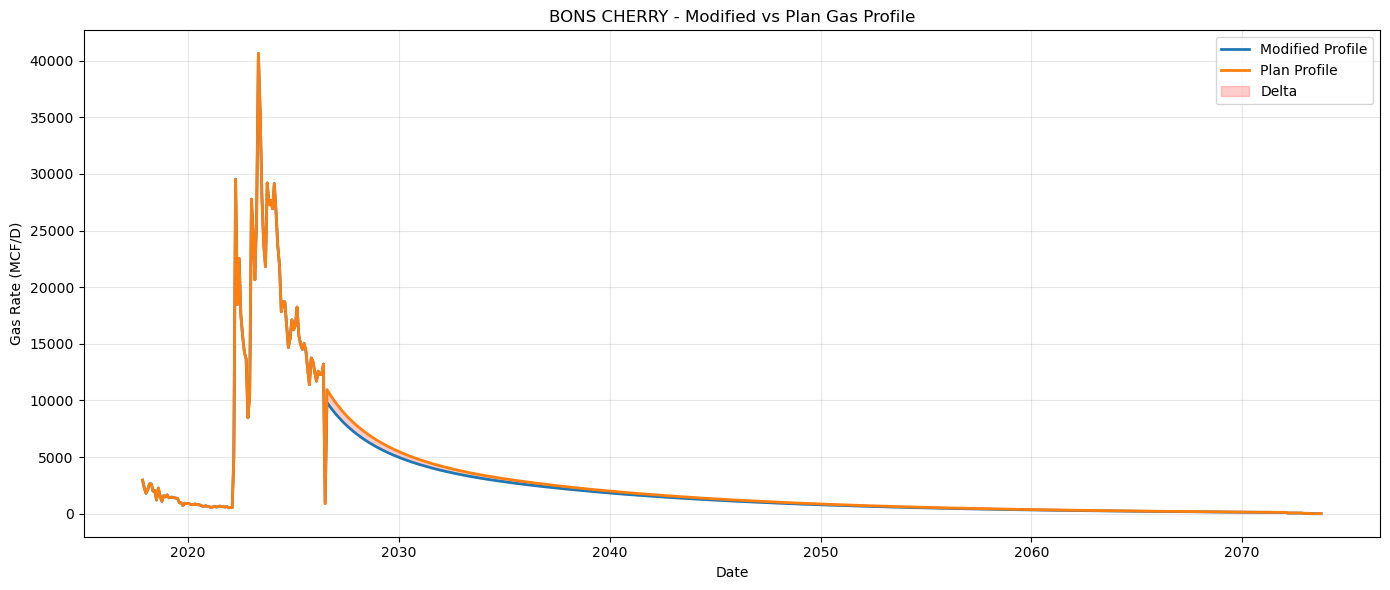

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison['Date'],
    comparison['Gas_MCFD_Modified'],
    label='Modified Profile',
    linewidth=2
)

plt.plot(
    comparison['Date'],
    comparison['Gas_MCFD_Plan'],
    label='Plan Profile',
    linewidth=2
)

plt.fill_between(
    comparison['Date'],
    comparison['Gas_MCFD_Modified'],
    comparison['Gas_MCFD_Plan'],
    color='red',
    alpha=0.20,
    label='Delta'
)

plt.title('BONS CHERRY - Modified vs Plan Gas Profile')
plt.xlabel('Date')
plt.ylabel('Gas Rate (MCF/D)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Cumulative comparison

The final delta percentage is calculated as **(Modified - Plan) / Plan × 100**. Positive means Modified is higher; negative means Modified is lower.

In [27]:
# Build cumulative volumes on the aligned calendar-month comparison
comparison['Cum_Oil_BBL_Modified'] = comparison['Oil_BBL_Modified'].cumsum()
comparison['Cum_Oil_BBL_Plan'] = comparison['Oil_BBL_Plan'].cumsum()
comparison['Cum_Gas_MCF_Modified'] = comparison['Gas_MCF_Modified'].cumsum()
comparison['Cum_Gas_MCF_Plan'] = comparison['Gas_MCF_Plan'].cumsum()

comparison['Cum_Oil_Delta_BBL'] = comparison['Cum_Oil_BBL_Modified'] - comparison['Cum_Oil_BBL_Plan']
comparison['Cum_Gas_Delta_MCF'] = comparison['Cum_Gas_MCF_Modified'] - comparison['Cum_Gas_MCF_Plan']

final_oil_modified = comparison['Cum_Oil_BBL_Modified'].iloc[-1]
final_oil_plan = comparison['Cum_Oil_BBL_Plan'].iloc[-1]
final_gas_modified = comparison['Cum_Gas_MCF_Modified'].iloc[-1]
final_gas_plan = comparison['Cum_Gas_MCF_Plan'].iloc[-1]

final_oil_delta = final_oil_modified - final_oil_plan
final_gas_delta = final_gas_modified - final_gas_plan

final_oil_delta_pct = (final_oil_delta / final_oil_plan * 100) if final_oil_plan != 0 else np.nan
final_gas_delta_pct = (final_gas_delta / final_gas_plan * 100) if final_gas_plan != 0 else np.nan

print(f'Oil: Modified={final_oil_modified:,.0f} BBL | Plan={final_oil_plan:,.0f} BBL | Delta={final_oil_delta:+,.0f} BBL ({final_oil_delta_pct:+.2f}%)')
print(f'Gas: Modified={final_gas_modified:,.0f} MCF | Plan={final_gas_plan:,.0f} MCF | Delta={final_gas_delta:+,.0f} MCF ({final_gas_delta_pct:+.2f}%)')

Oil: Modified=10,862,727 BBL | Plan=10,952,500 BBL | Delta=-89,772 BBL (-0.82%)
Gas: Modified=59,131,286 MCF | Plan=61,806,124 MCF | Delta=-2,674,838 MCF (-4.33%)


## Cumulative oil — Modified vs Plan

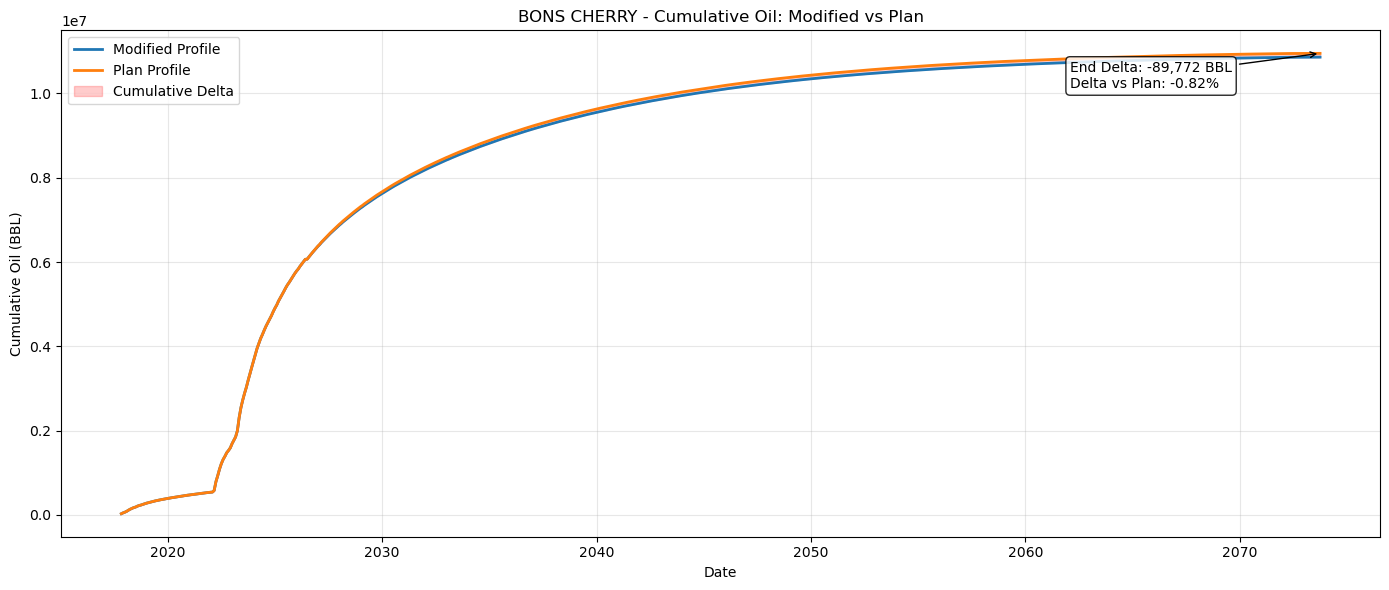

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(comparison['Date'], comparison['Cum_Oil_BBL_Modified'], label='Modified Profile', linewidth=2)
plt.plot(comparison['Date'], comparison['Cum_Oil_BBL_Plan'], label='Plan Profile', linewidth=2)
plt.fill_between(
    comparison['Date'],
    comparison['Cum_Oil_BBL_Modified'],
    comparison['Cum_Oil_BBL_Plan'],
    color='red', alpha=0.20, label='Cumulative Delta'
)
oil_text = f'End Delta: {final_oil_delta:+,.0f} BBL\nDelta vs Plan: {final_oil_delta_pct:+.2f}%'
plt.annotate(
    oil_text,
    xy=(comparison['Date'].iloc[-1], max(final_oil_modified, final_oil_plan)),
    xytext=(-180, -25), textcoords='offset points',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    arrowprops=dict(arrowstyle='->')
)
plt.title('BONS CHERRY - Cumulative Oil: Modified vs Plan')
plt.xlabel('Date')
plt.ylabel('Cumulative Oil (BBL)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Cumulative gas — Modified vs Plan

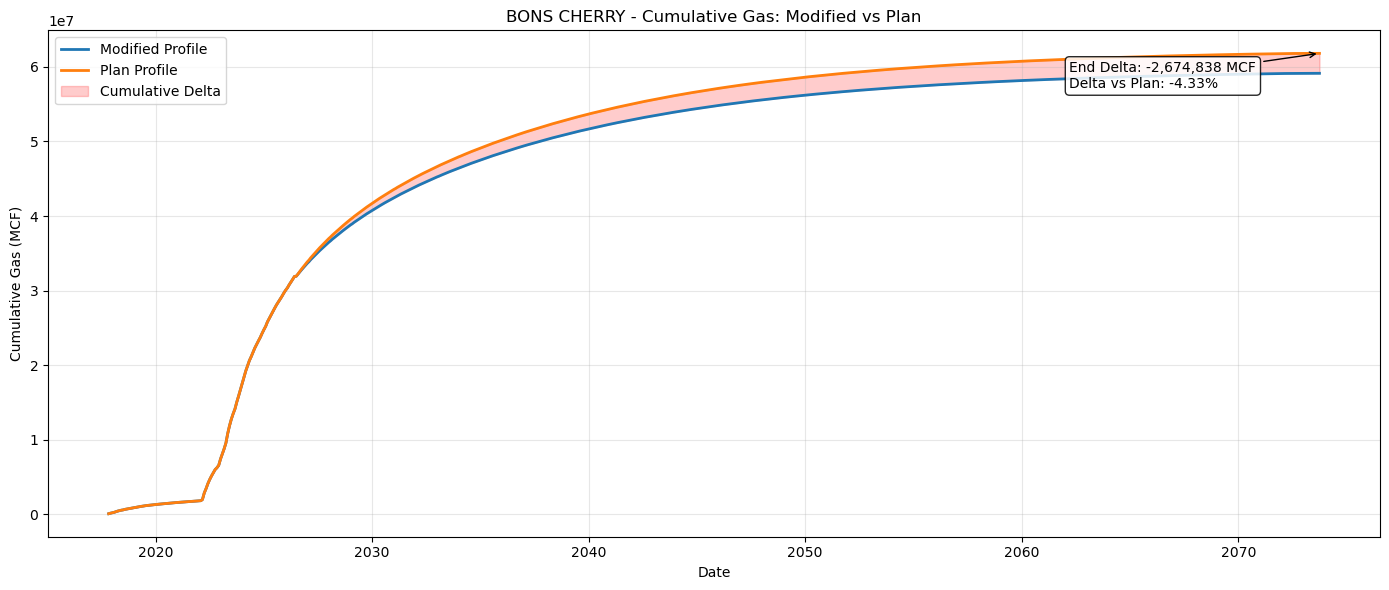

In [29]:
plt.figure(figsize=(14, 6))
plt.plot(comparison['Date'], comparison['Cum_Gas_MCF_Modified'], label='Modified Profile', linewidth=2)
plt.plot(comparison['Date'], comparison['Cum_Gas_MCF_Plan'], label='Plan Profile', linewidth=2)
plt.fill_between(
    comparison['Date'],
    comparison['Cum_Gas_MCF_Modified'],
    comparison['Cum_Gas_MCF_Plan'],
    color='red', alpha=0.20, label='Cumulative Delta'
)
gas_text = f'End Delta: {final_gas_delta:+,.0f} MCF\nDelta vs Plan: {final_gas_delta_pct:+.2f}%'
plt.annotate(
    gas_text,
    xy=(comparison['Date'].iloc[-1], max(final_gas_modified, final_gas_plan)),
    xytext=(-180, -25), textcoords='offset points',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    arrowprops=dict(arrowstyle='->')
)
plt.title('BONS CHERRY - Cumulative Gas: Modified vs Plan')
plt.xlabel('Date')
plt.ylabel('Cumulative Gas (MCF)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Final cumulative delta summary

In [30]:
cumulative_summary = pd.DataFrame({
    'Stream': ['Oil', 'Gas'],
    'Modified_Total': [final_oil_modified, final_gas_modified],
    'Plan_Total': [final_oil_plan, final_gas_plan],
    'Delta_Modified_minus_Plan': [final_oil_delta, final_gas_delta],
    'Delta_Percent_vs_Plan': [final_oil_delta_pct, final_gas_delta_pct],
    'Units': ['BBL', 'MCF']
})
display(cumulative_summary)
cumulative_summary.to_csv('Silvertip_Cumulative_Delta_Summary.csv', index=False)
comparison.to_csv('Silvertip_Modified_vs_Plan_Comparison.csv', index=False)

,Stream,Modified_Total,Plan_Total,Delta_Modified_minus_Plan,Delta_Percent_vs_Plan,Units
0,Oil,1.086273e+07,1.095250e+07,-8.977229e+04,-0.819651,BBL
1,Gas,5.913129e+07,6.180612e+07,-2.674838e+06,-4.327788,MCF


## 12. QA review

In [31]:
print('Modified QA issues:')
display(modified_qa[modified_qa['QA_Status'] != 'OK'])

print('Plan QA issues:')
display(plan_qa[plan_qa['QA_Status'] != 'OK'])

Modified QA issues:


,Case,Well_Name,Found_Production,Found_Forecast,Profile_Start,Last_Actual_Month,First_Forecast_Month_Used,Final_Profile_Months,Oil_BBL_50yr,Gas_MCF_50yr,QA_Status


Plan QA issues:


,Case,Well_Name,Found_Production,Found_Forecast,Profile_Start,Last_Actual_Month,First_Forecast_Month_Used,Final_Profile_Months,Oil_BBL_50yr,Gas_MCF_50yr,QA_Status


## 13. Save all CSV outputs

In [37]:
# ============================================================
# QUESTIONABLE-WELL SENSITIVITY
#
# Creates a SECOND Modified vs Plan facility profile with
# selected wells' FORECASTS removed from BOTH Modified and Plan.
#
# Historical production remains included.
#
# Assumes your multi-facility notebook already has:
#   modified_production
#   modified_forecast
#   plan_prod
#   plan_forecast
#   ctb_wells
#   build_case()
#   aggregate_facilities()
#   compare_facilities()
#
# If your function names differ slightly, change only those
# function calls near the middle of this cell.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ------------------------------------------------------------
# 1. ENTER QUESTIONABLE WELLS HERE
# Exact well names as they appear in ComboCurve exports.
# Add as many as needed.
# ------------------------------------------------------------
QUESTIONABLE_WELLS = [
    "ELM 55-1-36 UNIT 12HA",
    # "SECOND QUESTIONABLE WELL",
    # "THIRD QUESTIONABLE WELL",
]
# ------------------------------------------------------------
# 2. NORMALIZE WELL NAMES
# ------------------------------------------------------------
questionable_keys = {
    normalize_well_name(w)
    for w in QUESTIONABLE_WELLS
}
# ------------------------------------------------------------
# 3. MAKE COPIES
#
# Important: original Plan / Modified forecasts remain intact.
# ------------------------------------------------------------
modified_forecast_sens = modified_forecast.copy()
plan_forecast_sens = plan_forecast.copy()
# ------------------------------------------------------------
# 4. REMOVE QUESTIONABLE WELLS FROM FORECAST ONLY
#
# Production dataframes are NOT changed.
# ------------------------------------------------------------
modified_forecast_sens = modified_forecast_sens[
    ~modified_forecast_sens["Match_Name"].isin(
        questionable_keys
    )
].copy()
plan_forecast_sens = plan_forecast_sens[
    ~plan_forecast_sens["Match_Name"].isin(
        questionable_keys
    )
].copy()
print("Questionable wells removed from BOTH forecasts:")
for w in QUESTIONABLE_WELLS:
    print("   ", w)
print()
print(
    "Modified forecast rows remaining for questionable wells:",
    modified_forecast_sens[
        "Match_Name"
    ].isin(
        questionable_keys
    ).sum()
)
print(
    "Plan forecast rows remaining for questionable wells:",
    plan_forecast_sens[
        "Match_Name"
    ].isin(
        questionable_keys
    ).sum()
)
# ============================================================
# 5. REBUILD MODIFIED PROFILE
#
# Historical modified_production remains unchanged.
# ============================================================
mod_sens_well_level, mod_sens_qa = build_case_profile(
    "Modified - Questionable Wells Removed",
    modified_production,
    modified_forecast_sens,
    ctb_wells
)
# ============================================================
# 6. REBUILD PLAN PROFILE
#
# Historical plan_prod remains unchanged.
# ============================================================
plan_sens_well_level, plan_sens_qa = build_case_profile(
    "Plan - Questionable Wells Removed",
    plan_prod,
    plan_forecast_sens,
    ctb_wells
)
# ============================================================
# 7. AGGREGATE BY FACILITY
# ============================================================
mod_sens_facility = aggregate_facilities(
    mod_sens_well_level
)
plan_sens_facility = aggregate_facilities(
    plan_sens_well_level
)
# ============================================================
# 8. ALIGN MODIFIED AND PLAN
# ============================================================
questionable_comparison = compare_facilities(
    mod_sens_facility,
    plan_sens_facility
)
# ============================================================
# 9. PLOTTING FUNCTION
#
# Same format:
#   rate on left axis
#   cumulative on right axis
#   Modified vs Plan
#   cumulative delta shaded red
#   final cumulative delta annotated
#   peak rate noted
# ============================================================
def plot_questionable_sensitivity(
    df,
    facility,
    stream="Oil"
):
    d = (
        df[
            df["Facility"] == facility
        ]
        .copy()
        .sort_values("Date")
        .reset_index(drop=True)
    )
    if len(d) == 0:
        print(
            f"No data for {facility} - {stream}"
        )
        return
    # --------------------------------------------------------
    # Select stream
    # --------------------------------------------------------
    if stream == "Oil":
        rate_mod = "Oil_BPD_Modified"
        rate_plan = "Oil_BPD_Plan"
        vol_mod = "Oil_BBL_Modified"
        vol_plan = "Oil_BBL_Plan"
        rate_unit = "BPD"
        cum_unit = "BBL"
    else:
        rate_mod = "Gas_MCFD_Modified"
        rate_plan = "Gas_MCFD_Plan"
        vol_mod = "Gas_MCF_Modified"
        vol_plan = "Gas_MCF_Plan"
        rate_unit = "MCF/D"
        cum_unit = "MCF"
    # --------------------------------------------------------
    # Clean dates
    # --------------------------------------------------------
    d["Date"] = pd.to_datetime(
        d["Date"],
        errors="coerce"
    )
    d = d[
        d["Date"].notna()
    ].copy()
    # --------------------------------------------------------
    # Numeric cleanup
    # --------------------------------------------------------
    for col in [
        rate_mod,
        rate_plan,
        vol_mod,
        vol_plan
    ]:
        d[col] = pd.to_numeric(
            d[col],
            errors="coerce"
        ).fillna(0)
    d = d.replace(
        [np.inf, -np.inf],
        0
    )
    # --------------------------------------------------------
    # IMPORTANT:
    # Rebuild cumulative directly from monthly volumes
    # --------------------------------------------------------
    d["Cum_Modified"] = (
        d[vol_mod].cumsum()
    )
    d["Cum_Plan"] = (
        d[vol_plan].cumsum()
    )
    # --------------------------------------------------------
    # Convert for plotting
    # --------------------------------------------------------
    x = list(
        d["Date"]
        .dt.to_pydatetime()
    )
    modified_rate = (
        d[rate_mod]
        .to_numpy(dtype=float)
    )
    plan_rate = (
        d[rate_plan]
        .to_numpy(dtype=float)
    )
    modified_cum = (
        d["Cum_Modified"]
        .to_numpy(dtype=float)
    )
    plan_cum = (
        d["Cum_Plan"]
        .to_numpy(dtype=float)
    )
    # --------------------------------------------------------
    # Summary calculations
    # --------------------------------------------------------
    peak_modified = np.max(
        modified_rate
    )
    peak_plan = np.max(
        plan_rate
    )
    peak_facility = max(
        peak_modified,
        peak_plan
    )
    final_modified = (
        modified_cum[-1]
    )
    final_plan = (
        plan_cum[-1]
    )
    cumulative_delta = (
        final_modified
        -
        final_plan
    )
    if final_plan != 0:
        delta_pct = (
            cumulative_delta
            /
            final_plan
            *
            100
        )
        delta_pct_text = (
            f"{delta_pct:+.2f}%"
        )
    else:
        delta_pct = np.nan
        delta_pct_text = "N/A"
    # ========================================================
    # FIGURE
    # ========================================================
    fig, ax1 = plt.subplots(
        figsize=(14, 7)
    )
    ax2 = ax1.twinx()
    # --------------------------------------------------------
    # RATE CURVES
    # --------------------------------------------------------
    modified_line, = ax1.plot(
        x,
        modified_rate,
        linewidth=2,
        label="Modified Rate"
    )
    plan_line, = ax1.plot(
        x,
        plan_rate,
        linewidth=2,
        label="Plan Rate"
    )
    # --------------------------------------------------------
    # CUMULATIVE CURVES
    # --------------------------------------------------------
    modified_cum_line, = ax2.plot(
        x,
        modified_cum,
        linestyle="--",
        linewidth=2,
        label="Modified Cumulative"
    )
    plan_cum_line, = ax2.plot(
        x,
        plan_cum,
        linestyle="--",
        linewidth=2,
        label="Plan Cumulative"
    )
    # Red cumulative difference
    ax2.fill_between(
        x,
        modified_cum,
        plan_cum,
        color="red",
        alpha=0.15
    )
    # --------------------------------------------------------
    # Peak note
    # --------------------------------------------------------
    peak_note = (
        f"Peak Modified: "
        f"{peak_modified:,.0f} {rate_unit}\n"
        f"Peak Plan: "
        f"{peak_plan:,.0f} {rate_unit}\n"
        f"Peak Rate: "
        f"{peak_facility:,.0f} {rate_unit}"
    )
    ax1.text(
        0.015,
        0.97,
        peak_note,
        transform=ax1.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.88
        )
    )
    # --------------------------------------------------------
    # End cumulative delta note
    # --------------------------------------------------------
    delta_note = (
        f"End Cum Delta: "
        f"{cumulative_delta:+,.0f} "
        f"{cum_unit}\n"
        f"Delta vs Plan: "
        f"{delta_pct_text}"
    )
    ax2.text(
        0.98,
        0.92,
        delta_note,
        transform=ax2.transAxes,
        va="top",
        ha="right",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.88
        )
    )
    # --------------------------------------------------------
    # Titles
    # --------------------------------------------------------
    ax1.set_title(
        f"{facility} - {stream} Rate + Cumulative\n"
        f"Modified vs Plan — Questionable Forecasts Removed"
    )
    ax1.set_xlabel(
        "Date"
    )
    ax1.set_ylabel(
        f"{stream} Rate ({rate_unit})"
    )
    ax2.set_ylabel(
        f"Cumulative {stream} ({cum_unit})"
    )
    ax1.grid(
        True,
        alpha=0.30
    )
    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------
    ax1.legend(
        [
            modified_line,
            plan_line,
            modified_cum_line,
            plan_cum_line
        ],
        [
            "Modified Rate",
            "Plan Rate",
            "Modified Cumulative",
            "Plan Cumulative"
        ],
        loc="lower right"
    )
    plt.show()
# ============================================================
# 10. PRODUCE SECOND OIL + GAS PROFILE FOR EVERY FACILITY
# ============================================================
sensitivity_facilities = sorted(
    questionable_comparison[
        "Facility"
    ]
    .dropna()
    .unique()
)
for facility in sensitivity_facilities:
    print()
    print(
        "=" * 80
    )
    print(
        facility,
        "- QUESTIONABLE WELL SENSITIVITY"
    )
    print(
        "=" * 80
    )
    plot_questionable_sensitivity(
        questionable_comparison,
        facility,
        stream="Oil"
    )
    plot_questionable_sensitivity(
        questionable_comparison,
        facility,
        stream="Gas"
    )
# ============================================================
# 11. SAVE SECOND PROFILE DATA
# ============================================================
questionable_comparison.to_csv(
    "Facility_Modified_vs_Plan_Questionable_Wells_Removed.csv",
    index=False
)
mod_sens_qa.to_csv(
    "Modified_Questionable_Wells_Removed_QA.csv",
    index=False
)
plan_sens_qa.to_csv(
    "Plan_Questionable_Wells_Removed_QA.csv",
    index=False
)
print()
print(
    "Questionable-well sensitivity complete."
)


Questionable wells removed from BOTH forecasts:
    ELM 55-1-36 UNIT 12HA

Modified forecast rows remaining for questionable wells: 0
Plan forecast rows remaining for questionable wells: 0


<class 'ValueError'>: too many values to unpack (expected 2, got 3)

In [ ]:
# FACILITY QA SUMMARY FUNCTION
# Total cumulative, all-time peak rate, and rate at 1/1/2034
# ============================================================
def facility_QA(df, case_name):
    d = df.copy()
    d["Date"] = pd.to_datetime(d["Date"])
    # Total volume + peak rate for each facility
    out = d.groupby("Facility").agg(
        Oil_Cum_BBL=("Oil_BBL", "sum"),
        Gas_Cum_MCF=("Gas_MCF", "sum"),
        Peak_Oil_BPD=("Oil_BPD", "max"),
        Peak_Gas_MCFD=("Gas_MCFD", "max")
    )
    # Rates at 1/1/2034
    rate_2034 = (
        d[d["Date"] == pd.Timestamp("2034-01-01")]
        .set_index("Facility")[
            ["Oil_BPD", "Gas_MCFD"]
        ]
        .rename(columns={
            "Oil_BPD": "Oil_BPD_1_1_2034",
            "Gas_MCFD": "Gas_MCFD_1_1_2034"
        })
    )
    out = out.join(rate_2034)
    out.insert(0, "Case", case_name)
    return out.reset_index()
# ============================================================
# RUN FOR ALL FOUR CASES
# ============================================================
qa_base_modified = facility_QA(
    modified_facility,
    "Base Modified"
)
qa_base_plan = facility_QA(
    plan_facility,
    "Base Plan"
)
qa_questionable_modified = facility_QA(
    mod_sens_facility,
    "Modified - Questionable Wells Removed"
)
qa_questionable_plan = facility_QA(
    plan_sens_facility,
    "Plan - Questionable Wells Removed"
)
# Combine into one table
qa_all_cases = pd.concat([
    qa_base_modified,
    qa_base_plan,
    qa_questionable_modified,
    qa_questionable_plan
], ignore_index=True)
display(qa_all_cases)
